In [ ]:
!pip install biopython seaborn

# Environment setup & dependency imports
import os
import time
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from Bio import SeqIO
from Bio.Blast import NCBIWWW, NCBIXML
from IPython.display import display, HTML, Image
from datetime import datetime
import ipywidgets as widgets
from google.colab import files

# Create necessary folders
os.makedirs("source_seq", exist_ok=True)
os.makedirs("output_seq", exist_ok=True)
os.makedirs("logs", exist_ok=True)
print("✅ Environment setup complete")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 29.4 MB/s eta 0:00:00
✅ Environment setup complete


In [ ]:
# Display tool introduction
banner = HTML("""
<div style="background-color:#F0F8FF; padding: 20px; border-radius: 10px; border: 1px solid #4682B4;">
    <h1 style="text-align:center; color:#4682B4;">🔬 BLAST Identity Comparison Tool</h1>
    <p style="text-align:center; font-size:1.2em;">Comparing BLASTn and BLASTx performance across sequence lengths</p>
    <hr style="border-top: 1px solid #4682B4;">
    <p><b>Purpose:</b> This tool compares the identity performance of BLASTn and BLASTx algorithms across DNA sequences of varying lengths.</p>
    <p><b>Workflow:</b></p>
    <ol>
        <li>Fetch sequences directly from NCBI</li>
        <li>Run BLASTn and BLASTx on sequences at 100bp, 500bp, 1000bp, and 2000bp lengths</li>
        <li>Summarize results in a CSV file</li>
        <li>Generate visualizations comparing algorithm performance</li>
        <li>Download all results for offline analysis</li>
    </ol>
    <p><b>Source sequences:</b></p>
    <ol>
        <li>Human mitochondrion (NC_012920)</li>
        <li>E. coli (NC_000913.3)</li>
        <li>Mouse mitochondrion (NC_005089.1)</li>
        <li>Globin (NG_005905.2)</li>
    </ol>
    <p style="text-align:center; font-style:italic;">CS123A Term Project - Spring 2025</p>
</div>
""")
display(banner)


In [ ]:
# Download 4 FASTA sequences from NCBI
from Bio import Entrez

Entrez.email = "jisheng.jiang@sjsu.edu"  # ❗Please replace with your own email

def fetch_sequence(accession, output_file):
    print(f"📥 Fetching {accession}...")
    handle = Entrez.efetch(db="nucleotide", id=accession, rettype="fasta", retmode="text")
    sequence = handle.read()
    handle.close()
    with open(output_file, "w") as f:
        f.write(sequence)
    print(f"✅ Saved to {output_file}")

# Accession numbers of the sequences to be downloaded
accessions = {
    "1sequence.fasta": "NC_012920",
    "2sequence.fasta": "NC_000913.3",
    "3sequence.fasta": "NC_005089.1",
    "4sequence.fasta": "NG_005905.2"
}

# Perform downloads
for filename, acc in accessions.items():
    fetch_sequence(acc, f"source_seq/{filename}")

print("✅ All sequences downloaded")


📥 Fetching NC_012920...
✅ Saved to source_seq/1sequence.fasta
📥 Fetching NC_000913.3...
✅ Saved to source_seq/2sequence.fasta
📥 Fetching NC_005089.1...
✅ Saved to source_seq/3sequence.fasta
📥 Fetching NG_005905.2...
✅ Saved to source_seq/4sequence.fasta
✅ All sequences downloaded


In [ ]:
# Core BLAST functions: run, summarize, visualize
def batch_run_blast():
    from Bio.Blast import NCBIWWW
    fasta_files = [f for f in os.listdir("source_seq") if f.endswith(".fasta")]
    lengths = [100]  # Test mode: only run 100bp

    for fasta in fasta_files[:1]:  # Only process the first sequence
        record = SeqIO.read(f"source_seq/{fasta}", "fasta")
        seq_id = os.path.splitext(fasta)[0]

        for L in lengths:
            if len(record.seq) < L:
                continue
            sequence = str(record.seq[:L])
            label = f"{seq_id}_{L}bp"

            for algo, db in [("blastn", "nt"), ("blastx", "nr")]:
                filename = f"output_seq/{algo}_{label}.xml"
                if os.path.exists(filename):
                    print(f"✅ {filename} already exists, skipping")
                    continue
                try:
                    print(f"🚀 Running {algo.upper()}: {label}")
                    result_handle = NCBIWWW.qblast(algo, db, sequence)
                    with open(filename, "w") as out:
                        out.write(result_handle.read())
                    print(f"✅ Saved to {filename}")
                except Exception as e:
                    print(f"❌ {algo.upper()} failed to run: {e}")

def summarize_results():
    records = []
    for xml_file in glob.glob("output_seq/blast*_*bp.xml"):
        match = re.match(r"output_seq/(blast[nx])_(\w+)_([0-9]+)bp\.xml", xml_file)
        if not match:
            continue
        algo, fname, length = match.groups()
        with open(xml_file) as handle:
            try:
                record = NCBIXML.read(handle)
                if not record.alignments:
                    continue
                hsp = record.alignments[0].hsps[0]
                identity = 100 * hsp.identities / hsp.align_length
                records.append({
                    "algorithm": algo,
                    "file": fname,
                    "length": int(length),
                    "identity_percent": round(identity, 2),
                    "evalue": hsp.expect,
                    "score": hsp.score
                })
            except Exception as e:
                print(f"⚠️ Failed to parse {xml_file}: {e}")
    df = pd.DataFrame(records)
    if not df.empty:
        df.to_csv("blast_summary.csv", index=False)
        print("✅ Summary saved as blast_summary.csv")
    return df

def plot_results(df):
    if df.empty:
        print("⚠️ No data to visualize")
        return
    df['Algorithm'] = df['algorithm'].apply(lambda x: 'BLASTn' if x == 'blastn' else 'BLASTx')

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x="Algorithm", y="identity_percent")
    plt.title("Identity % Comparison")
    plt.ylabel("Identity %")
    plt.savefig("plot_identity_compare.png")
    plt.show()


🚦 Test mode activated (1 sequence @ 100bp)
🚀 Running BLASTN: 2sequence_100bp
✅ Saved to output_seq/blastn_2sequence_100bp.xml
🚀 Running BLASTX: 2sequence_100bp
✅ Saved to output_seq/blastx_2sequence_100bp.xml
✅ Summary saved as blast_summary.csv


,algorithm,file,length,identity_percent,evalue,score
0,blastx,2sequence,100,100.0,6.532860e-12,153.0
1,blastn,2sequence,100,100.0,1.148000e-41,200.0


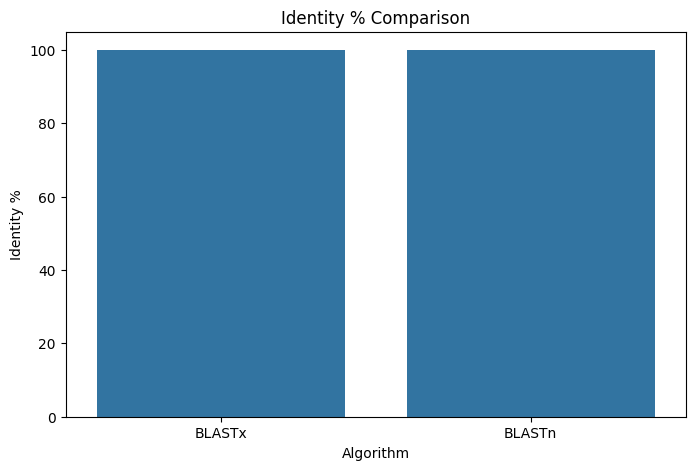

In [ ]:
# Quick test run: 1 sequence × 100bp
def run_test_workflow():
    print("🚦 Test mode activated (1 sequence @ 100bp)")
    batch_run_blast()
    df = summarize_results()
    display(df)
    plot_results(df)

run_test_workflow()


In [ ]:
# Top BLAST Hits viewer tool
# Get available options
def get_available_options():
    files = glob.glob("output_seq/blast*_*bp.xml")
    sequences = set()
    lengths = set()
    for file in files:
        match = re.match(r"output_seq/blast[nx]_(\w+)_([0-9]+)bp\.xml", file)
        if match:
            sequences.add(match.group(1))
            lengths.add(match.group(2) + "bp")
    return sorted(sequences), sorted(lengths)


# Get available options
def get_available_options():
    files = glob.glob("output_seq/blast*_*bp.xml")
    sequences = set()
    lengths = set()
    for file in files:
        match = re.match(r"output_seq/blast[nx]_(\w+)_([0-9]+)bp\.xml", file)
        if match:
            sequences.add(match.group(1))
            lengths.add(match.group(2) + "bp")
    return sorted(sequences), sorted(lengths)


In [ ]:
# Check BLAST progress
def check_progress():
    output_files = glob.glob("output_seq/blast*_*bp.xml")
    if not output_files:
        print("❌ No BLAST result files found")
        return pd.DataFrame()

    sequences, lengths, algorithms = set(), set(), set()
    for file in output_files:
        match = re.match(r"output_seq/(blast[nx])_(\w+)_([0-9]+)bp\.xml", file)
        if match:
            algo, seq, length = match.groups()
            sequences.add(seq)
            lengths.add(int(length))
            algorithms.add(algo)

    total = len(sequences) * len(lengths) * len(algorithms)
    done = len(output_files)
    print(f"✅ {done}/{total} BLAST comparisons completed ({100*done/total:.1f}%)")
    return pd.DataFrame({
        "Sequences": [sorted(sequences)],
        "Lengths": [sorted(lengths)],
        "Algorithms": [sorted(algorithms)],
        "Completed Files": [done]
    })

# Resume unfinished tasks
def resume_blast_runs():
    output_files = glob.glob("output_seq/blast*_*bp.xml")
    done_set = set(output_files)

    fasta_files = [f for f in os.listdir("source_seq") if f.endswith(".fasta")]
    lengths = [100, 500, 1000, 2000]
    to_run = []

    for fasta in fasta_files:
        record = SeqIO.read(f"source_seq/" + fasta, "fasta")
        seq_id = os.path.splitext(fasta)[0]
        for L in lengths:
            if len(record.seq) < L:
                continue
            label = f"{seq_id}_{L}bp"
            for algo in ["blastn", "blastx"]:
                filename = f"output_seq/{algo}_{label}.xml"
                if filename not in done_set:
                    to_run.append((algo, seq_id, record, L, filename))

    print(f"🔁 Found {len(to_run)} unfinished BLAST runs, starting execution...")
    for algo, seq_id, record, L, filename in to_run:
        db = "nt" if algo == "blastn" else "nr"
        sequence = str(record.seq[:L])
        try:
            print(f"⚡ {algo.upper()} - {seq_id} ({L}bp)")
            result_handle = NCBIWWW.qblast(algo, db, sequence)
            with open(filename, "w") as f:
                f.write(result_handle.read())
            print(f"✅ Completed and saved: {filename}")
        except Exception as e:
            print(f"❌ Error: {e}")


In [ ]:
# Analyze runtime
def analyze_runtime():
    log_files = glob.glob("logs/*.log")
    timing_data = []

    for file in log_files:
        with open(file, "r") as f:
            content = f.read()
            entries = content.split("Running content logs:")
            for entry in entries[1:]:
                try:
                    algo = re.search(r"algorithms: (\w+)", entry).group(1)
                    seq = re.search(r"Objective: (\w+)_", entry).group(1)
                    length = int(re.search(r"_(\d+)bp", entry).group(1))
                    time_match = re.search(r"Runtime: ([\d\.]+)s", entry)
                    if time_match:
                        runtime = float(time_match.group(1))
                        timing_data.append({
                            "Algorithm": algo.upper(),
                            "Sequence": seq,
                            "Length": length,
                            "Runtime (s)": runtime
                        })
                except:
                    continue

    df = pd.DataFrame(timing_data)
    if df.empty:
        print("⚠️ No available log data")
        return
    display(df)

    # Visualization
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x="Length", y="Runtime (s)", hue="Algorithm")
    plt.title("BLAST Runtime Comparison")
    plt.grid(True)
    plt.savefig("plot_runtime_analysis.png")
    plt.show()


In [ ]:
# Install dependencies (skip if already installed)
!pip install biopython seaborn

# Import libraries
import os, time, re, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from Bio import Entrez, SeqIO
from Bio.Blast import NCBIWWW, NCBIXML
from Bio.Seq import Seq
from IPython.display import display

# Create required folders
os.makedirs("source_seq", exist_ok=True)
os.makedirs("source_protein", exist_ok=True)
os.makedirs("output_seq", exist_ok=True)
os.makedirs("logs", exist_ok=True)
print("✅ Folders are ready")

# Set email for NCBI access
Entrez.email = "jisheng.jiang@sjsu.edu"

# Download DNA sequences
accessions = {
    "1sequence.fasta": "NC_012920",
    "2sequence.fasta": "NC_000913.3",
    "3sequence.fasta": "NC_005089.1",
    "4sequence.fasta": "NG_005905.2"
}
for filename, acc in accessions.items():
    out_path = f"source_seq/{filename}"
    if not os.path.exists(out_path):
        print(f"📥 Downloading {acc}")
        with Entrez.efetch(db="nucleotide", id=acc, rettype="fasta", retmode="text") as handle:
            data = handle.read()
            with open(out_path, "w") as f:
                f.write(data)
        print(f"✅ Saved to {out_path}")

# Auto-translate to protein (for blastp and tblastn)
for fasta in glob.glob("source_seq/*.fasta"):
    record = SeqIO.read(fasta, "fasta")
    protein_seq = record.seq.translate(to_stop=True)  # Translate only one segment
    new_record = record[:len(protein_seq)*3]
    new_record.seq = protein_seq
    out_path = f"source_protein/{os.path.basename(fasta)}"
    SeqIO.write(new_record, out_path, "fasta")

print("✅ DNA sequences translated")

# Set parameters for execution
algorithms = {
    # "blastn": {"db": "nt", "input": "nucleotide"},
    "blastx": {"db": "nr", "input": "nucleotide"},
    "blastp": {"db": "nr", "input": "protein"},
    "tblastn": {"db": "nt", "input": "protein"}
}
lengths = [100, 500, 1000, 2000]
log_time = datetime.now().strftime("%Y%m%d_%H%M%S")
log_path = f"logs/blast_run_{log_time}.log"
summary = []

# Main execution loop
for algo, config in algorithms.items():
    input_dir = "source_seq" if config["input"] == "nucleotide" else "source_protein"
    for fasta in sorted(os.listdir(input_dir)):
        if not fasta.endswith(".fasta"):
            continue
        record = SeqIO.read(f"{input_dir}/{fasta}", "fasta")
        seq_id = os.path.splitext(fasta)[0]
        for L in lengths:
            if len(record.seq) < L:
                print(f"⚠️ {fasta} too short for {L}bp")
                continue
            sub_seq = str(record.seq[:L])
            label = f"{seq_id}_{L}bp"
            output_file = f"output_seq/{algo}_{label}.xml"

            if os.path.exists(output_file):
                print(f"⏩ {output_file} exists, skipping")
                continue

            print(f"🚀 Running {algo.upper()} on {label}")
            try:
                start = time.time()
                result_handle = NCBIWWW.qblast(algo, config["db"], sub_seq)
                with open(output_file, "w") as f:
                    f.write(result_handle.read())
                elapsed = round(time.time() - start, 2)

                # Parse result
                with open(output_file) as result_f:
                    blast_record = NCBIXML.read(result_f)
                    if blast_record.alignments:
                        hsp = blast_record.alignments[0].hsps[0]
                        identity = 100 * hsp.identities / hsp.align_length
                        evalue = hsp.expect
                        score = hsp.score
                    else:
                        identity = evalue = score = "-"
                summary.append({
                    "algorithm": algo,
                    "sequence": seq_id,
                    "length": L,
                    "runtime_s": elapsed,
                    "identity_percent": identity,
                    "evalue": evalue,
                    "score": score
                })

                # Write log
                with open(log_path, "a") as log:
                    log.write(f"Algorithm: {algo.upper()}\n")
                    log.write(f"Target: {seq_id}\n")
                    log.write(f"Length: {L}bp\n")
                    log.write(f"Runtime: {elapsed}s\n")
                    log.write(f"Identity: {identity}\n")
                    log.write(f"E-value: {evalue}\n")
                    log.write(f"Score: {score}\n")
                    log.write(f"{'-'*40}\n")

                print(f"✅ Done in {elapsed}s")

            except Exception as e:
                print(f"❌ Error running {algo} on {label}: {e}")

# Save summary
df = pd.DataFrame(summary)
df.to_csv("blast_summary.csv", index=False)
print("📄 Summary saved to blast_summary.csv")
display(df)


✅ Folders are ready
✅ DNA sequences translated
🚀 Running BLASTX on 1sequence_100bp


/usr/local/lib/python3.11/dist-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


✅ Done in 241.25s
🚀 Running BLASTX on 1sequence_500bp
✅ Done in 199.95s
🚀 Running BLASTX on 1sequence_1000bp
✅ Done in 440.01s
🚀 Running BLASTX on 1sequence_2000bp
✅ Done in 499.94s
⏩ output_seq/blastx_2sequence_100bp.xml exists, skipping
🚀 Running BLASTX on 2sequence_500bp
✅ Done in 320.06s
🚀 Running BLASTX on 2sequence_1000bp
✅ Done in 320.15s
🚀 Running BLASTX on 2sequence_2000bp
✅ Done in 439.94s
🚀 Running BLASTX on 3sequence_100bp
✅ Done in 379.91s
🚀 Running BLASTX on 3sequence_500bp
✅ Done in 559.96s
🚀 Running BLASTX on 3sequence_1000bp
